In [47]:
import pandas as pd
import matplotlib.pyplot as plt
#import numpy as np

In [48]:
df = pd.read_csv(r'D:\renzo stuff\Project 1\titanic-dataset.csv')

In [22]:
df = pd.read_csv(r'D:\renzo stuff\Project 1\cleaned_titanic_train.csv')

In [49]:
df.head(10)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


CLEANING DATA

# EDITING Columns


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [50]:
df.columns = df.columns.str.replace(' ', '_').str.lower()

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   name         891 non-null    object 
 4   sex          891 non-null    object 
 5   age          714 non-null    float64
 6   sibsp        891 non-null    int64  
 7   parch        891 non-null    int64  
 8   ticket       891 non-null    object 
 9   fare         891 non-null    float64
 10  cabin        204 non-null    object 
 11  embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# dups and nulls cleaning

In [52]:
df.duplicated().sum()

np.int64(0)

In [53]:
df.isnull().sum()


passengerid      0
survived         0
pclass           0
name             0
sex              0
age            177
sibsp            0
parch            0
ticket           0
fare             0
cabin          687
embarked         2
dtype: int64

# fixing incorrect formats and/or values


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   name         891 non-null    object 
 4   sex          891 non-null    object 
 5   age          714 non-null    float64
 6   sibsp        891 non-null    int64  
 7   parch        891 non-null    int64  
 8   ticket       891 non-null    object 
 9   fare         891 non-null    float64
 10  cabin        204 non-null    object 
 11  embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


1. Dealing with null AGE values by creating a median that is grouped by name/title of the passengers

Creating a TITLE column

In [55]:
df.name.str.extract(' ([A-Za-z]+)\.')

,0
0,Mr
1,Mrs
2,Miss
3,Mrs
4,Mr
...,...
886,Rev
887,Miss
888,Miss
889,Mr


In [56]:
df['title'] = df.name.str.extract(r' ([A-Za-z]+)\.')


In [57]:
df.head(5)

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr


Applying MEDIAN

In [58]:
df['age'] = df['age'].fillna(df.groupby('title')['age'].transform('median'))

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   name         891 non-null    object 
 4   sex          891 non-null    object 
 5   age          891 non-null    float64
 6   sibsp        891 non-null    int64  
 7   parch        891 non-null    int64  
 8   ticket       891 non-null    object 
 9   fare         891 non-null    float64
 10  cabin        204 non-null    object 
 11  embarked     889 non-null    object 
 12  title        891 non-null    object 
dtypes: float64(2), int64(5), object(6)
memory usage: 90.6+ KB


2. Dealing CABIN nulls

In [60]:
df['cabin'] = df['cabin'].fillna('Unknown')

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   name         891 non-null    object 
 4   sex          891 non-null    object 
 5   age          891 non-null    float64
 6   sibsp        891 non-null    int64  
 7   parch        891 non-null    int64  
 8   ticket       891 non-null    object 
 9   fare         891 non-null    float64
 10  cabin        891 non-null    object 
 11  embarked     889 non-null    object 
 12  title        891 non-null    object 
dtypes: float64(2), int64(5), object(6)
memory usage: 90.6+ KB


In [ ]:
df.head(10)

3. Dealing with embarked NULLS

In [62]:
df['embarked'].isnull().sum()

np.int64(2)

In [63]:
df['embarked'].value_counts()

embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [64]:
df['embarked'].mode()

0    S
Name: embarked, dtype: object

In [65]:
df['embarked'].fillna('S')

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: embarked, Length: 891, dtype: object

# EDA

In [66]:
df.head(6)


,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S,Mr
5,6,0,3,"Moran, Mr. James",male,30.0,0,0,330877,8.4583,Unknown,Q,Mr


In [67]:
df['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

SAMPLE SHOWCASE 1: Survival rate of passengers


In [ ]:
df['survived_label'] = df['survived'].map({0: 'Did Not Survive', 1: 'Survived'})
df['survived_label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.ylabel('')  # removes "survived" label on side
plt.title('Survival Distribution')
plt.show()

SHOWCASE 1: Survival rate of passengers

surivors: 342 non-survivors:549 Total passengers: 891


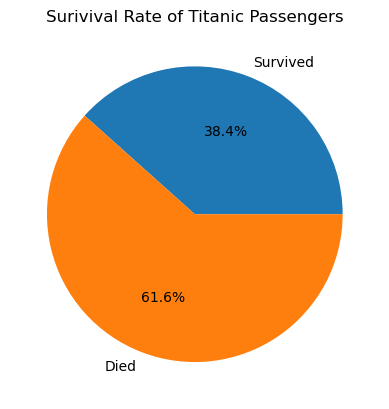

In [75]:
# df['survived'].tolist().count(0)
survivors = df['survived'].tolist().count(1)
deceased = df['survived'].tolist().count(0)

print(f'surivors: {survivors}', f'non-survivors:{deceased}', f'Total passengers: {survivors+deceased}')

categories = ['Survived','Died']
values = [survivors, deceased]

plt.pie(values, 
        labels=categories,
        autopct = '%1.1f%%')

plt.title('Surivival Rate of Titanic Passengers')

plt.show()



SHOWCASE 2: SURVIVAL RATE OF MEN VS WOMEN


In [ ]:
df.info()

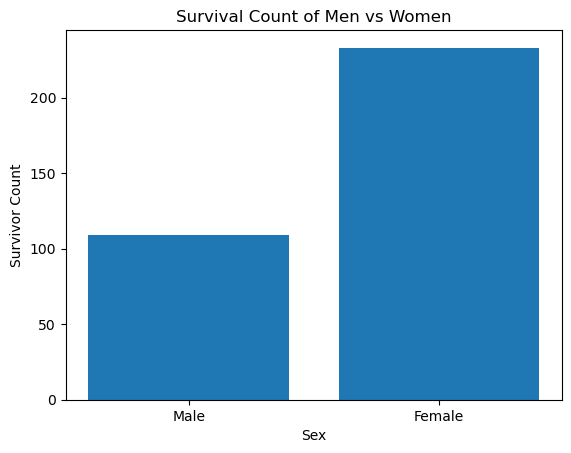

In [69]:
male_survivors = df[(df['sex'] == 'male') & (df['survived'] == 1)]['passengerid'].count()
female_survivors = df[(df['sex'] == 'female') & (df['survived'] == 1)]['passengerid'].count()

x = np.array(['Male','Female'])
y = np.array([male_survivors, female_survivors])

plt.bar(x,y)
plt.title('Survival Count of Men vs Women')
plt.xlabel('Sex')
plt.ylabel('Survivor Count')
plt.show()


SHOWCASE 3: Survival Rate of Different Wealth Classes


In [ ]:
df.head(5)

In [ ]:
df['pclass'].unique()

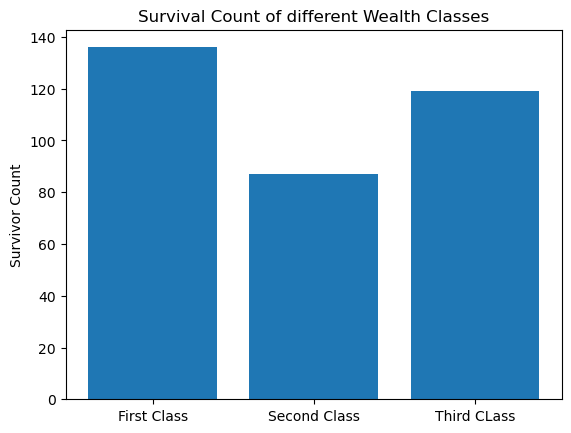

In [70]:
class1_survivors = df[(df['pclass'] == 1) & (df['survived'] == 1)]['passengerid'].count()
class2_survivors = df[(df['pclass'] == 2) & (df['survived'] == 1)]['passengerid'].count()
class3_survivors = df[(df['pclass'] == 3) & (df['survived'] == 1)]['passengerid'].count()

x = np.array(['First Class','Second Class','Third CLass',])
y = np.array([class1_survivors, class2_survivors , class3_survivors])

plt.bar(x,y)
plt.title('Survival Count of different Wealth Classes')
#plt.xlabel('Passenger Classes')
plt.ylabel('Survivor Count')
plt.show()

SHOWCASE 4: Survival Rate of passengers traveling as family vs no family


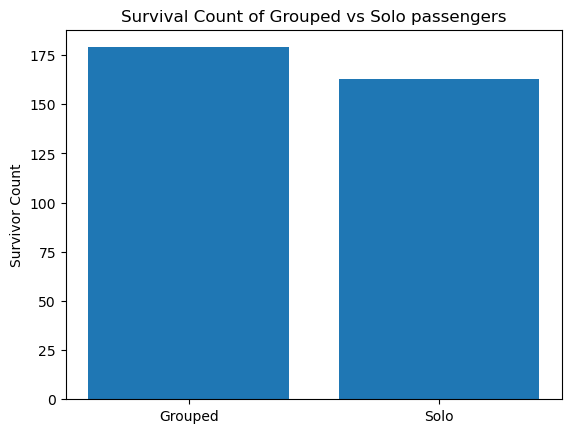

In [71]:
#grouped = 'people with >=1 sibsp or >=1 parch'
#solo = 'people with 0 sibsp & 0 parch'

grouped = df[(df['sibsp'] >= 1)  & (df['survived'] == 1) | (df['parch'] >= 1) & (df['survived'] == 1)]['passengerid'].count()
solo = df[(df['sibsp'] == 0) & (df['parch'] == 0) & (df['survived'] == 1)]['passengerid'].count()

x = np.array(['Grouped', 'Solo'])
y = np.array([grouped, solo])


plt.bar(x,y)
plt.ylabel('Survivor Count')
plt.title('Survival Count of Grouped vs Solo passengers')
plt.show()

